In [1]:
!pip install kagglehub[pandas-datasets]


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


<h1>Treinando o algoritmo de clusterização HDBSCAN</h1>

In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "iris.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "himanshunakrani/iris-dataset",
  file_path
)

print("First 5 records:", df.head())

c:\Users\maria\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\maria\AppData\Local\Temp\ipykernel_17608\220261672.py:8: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


First 5 records:    sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [3]:
from sklearn.cluster import HDBSCAN

def aplicar_hdbscan(dados, min_cluster_size):
    hdbscan = HDBSCAN(min_cluster_size=min_cluster_size)
    hdbscan.fit(dados)
    return hdbscan.labels_

def metricas_(dados,labels):
    from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

    silhouette = silhouette_score(dados, labels)
    calinski_harabasz = calinski_harabasz_score(dados, labels)
    davies_bouldin = davies_bouldin_score(dados, labels)

    return {
        'Silhouette Score': silhouette,
        'Calinski-Harabasz Index': calinski_harabasz,
        'Davies-Bouldin Index': davies_bouldin
    }

def visualizar_clusters(dados_2d, labels):
    import matplotlib.pyplot as plt

    plt.figure(figsize=(8, 6))
    plt.scatter(dados_2d.iloc[:, 0], dados_2d.iloc[:, 1], c=labels, cmap='viridis', marker='o')
    plt.title('Clusters Identificados pelo HDBSCAN')
    plt.xlabel(dados_2d.columns[0])
    plt.ylabel(dados_2d.columns[1])
    plt.colorbar(label='Cluster Label')
    plt.show()

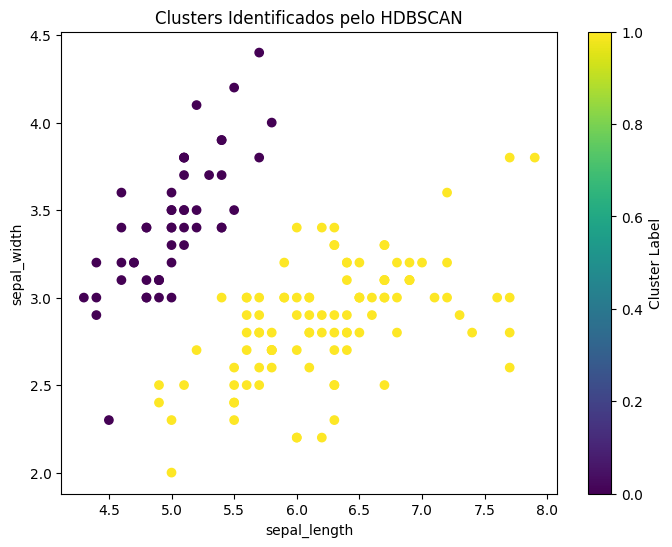

In [ ]:
aplicar_hdbscan(df[['sepal_length',  'sepal_width', 'petal_length', 'petal_width']], 5)

visualizar_clusters(df[['sepal_length', 'sepal_width']], aplicar_hdbscan(df[['sepal_length',  'sepal_width', 'petal_length', 'petal_width']], 5))

In [5]:
metricas_(df[['sepal_length',  'sepal_width', 'petal_length', 'petal_width']], aplicar_hdbscan(df[['sepal_length',  'sepal_width', 'petal_length', 'petal_width']], 5))

{'Silhouette Score': 0.6863930543445408,
 'Calinski-Harabasz Index': 501.9248640964316,
 'Davies-Bouldin Index': 0.3835952094491397}

In [6]:
from sklearn.cluster import DBSCAN


def aplicar_dbscan(dados, eps, min_samples):
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    dbscan.fit(dados)
    return dbscan.labels_

def metricas_avaliacao(dados, labels):
    from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

    silhouette = silhouette_score(dados, labels)
    calinski_harabasz = calinski_harabasz_score(dados, labels)
    davies_bouldin = davies_bouldin_score(dados, labels)

    return {
        'Silhouette Score': silhouette,
        'Calinski-Harabasz Index': calinski_harabasz,
        'Davies-Bouldin Index': davies_bouldin
    }

def visualizar_clustering(dados_2d, labels):
    import matplotlib.pyplot as plt

    plt.figure(figsize=(8, 6))
    plt.scatter(dados_2d.iloc[:, 0], dados_2d.iloc[:, 1], c=labels, cmap='viridis', marker='o')
    plt.title('Clusters Identificados pelo DBSCAN')
    plt.xlabel(dados_2d.columns[0])
    plt.ylabel(dados_2d.columns[1])
    plt.colorbar(label='Cluster Label')
    plt.show()

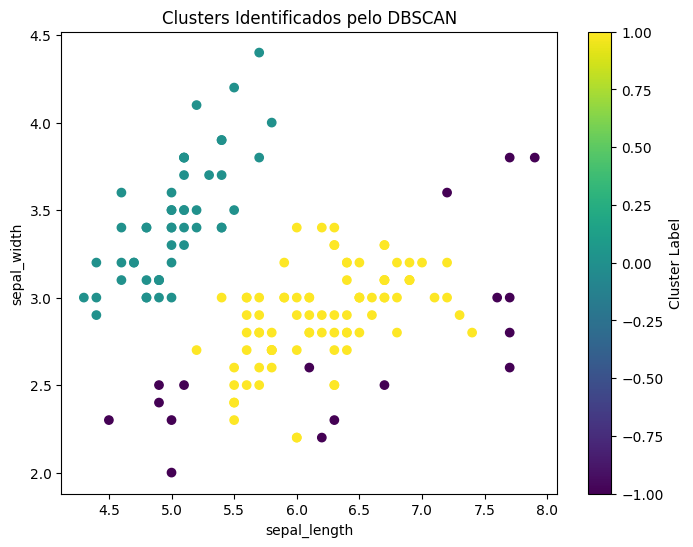

In [7]:
aplicar_dbscan(df[['sepal_length',  'sepal_width', 'petal_length', 'petal_width']], 0.5, 5)
visualizar_clustering(df[['sepal_length', 'sepal_width']], aplicar_dbscan(df[['sepal_length',  'sepal_width', 'petal_length', 'petal_width']], 0.5, 5))

In [8]:
metricas_avaliacao(df[['sepal_length',  'sepal_width', 'petal_length', 'petal_width']], aplicar_dbscan(df[['sepal_length',  'sepal_width', 'petal_length', 'petal_width']], 0.5, 5))

{'Silhouette Score': 0.485842354600955,
 'Calinski-Harabasz Index': 219.87022703461665,
 'Davies-Bouldin Index': 7.222826995273629}